# Bizkaibus ML — Paso 1: Carga, limpieza y construcción del DataFrame

**Líneas seleccionadas:** A3916, A3933, A3915, A3247, A3527  
**Período de entrenamiento:** 2021–2024 (con lag de 2020)  
**Período de test:** 2025  
**Objetivo:** Predecir viajeros mensuales por línea para 2026


## 1. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

# Líneas objetivo
LINEAS = ['A3916', 'A3933', 'A3915', 'A3247', 'A3527']
NOMBRES = {
    'A3916': 'BILBAO - ERMUA - ONDARROA',
    'A3933': 'BILBAO - DURANGO (Autopista)',
    'A3915': 'BILBAO - DURANGO - ONDARROA',
    'A3247': 'BILBAO - Aeropuerto',
    'A3527': 'BILBAO - MUNGIA - BERMEO'
}

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. Carga y concatenación de todos los CSVs

In [2]:
# Ruta a los CSVs — ajusta si es necesario
DATA_PATH = 'data/bizkaibus/*.csv'

files = glob.glob(DATA_PATH)
print(f'Archivos encontrados: {len(files)}')
for f in sorted(files):
    print(f'  {f}')

Archivos encontrados: 18
  data/bizkaibus\2020_biz_dic.csv
  data/bizkaibus\2020_biz_jun.csv
  data/bizkaibus\2021_biz_dic.csv
  data/bizkaibus\2021_biz_jun.csv
  data/bizkaibus\2022_biz_dic.csv
  data/bizkaibus\2022_biz_jun.csv
  data/bizkaibus\2023_biz_dic.csv
  data/bizkaibus\2023_biz_jun.csv
  data/bizkaibus\2023_biz_mar.csv
  data/bizkaibus\2023_biz_sept.csv
  data/bizkaibus\2024_biz_dic.csv
  data/bizkaibus\2024_biz_jun.csv
  data/bizkaibus\2024_biz_mar.csv
  data/bizkaibus\2024_biz_sept.csv
  data/bizkaibus\2025_biz_dic.csv
  data/bizkaibus\2025_biz_jun.csv
  data/bizkaibus\2025_biz_mar.csv
  data/bizkaibus\2025_biz_sept.csv


In [3]:
# Carga y concatenación
dfs = []
for f in files:
    df = pd.read_csv(f, encoding='utf-8-sig')
    dfs.append(df)

df_raw = pd.concat(dfs, ignore_index=True)
print(f'Shape total: {df_raw.shape}')
print(f'Años presentes: {sorted(df_raw["EKITALDIA/EJERCICIO"].unique())}')
df_raw.head(3)

Shape total: (6852, 44)
Años presentes: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,_id,EKITALDIA/EJERCICIO,HILABETE/MES,ZENBAKIA/CODIGO,LERROA/LINEA,CREDITRANS/CREDITRANS,CREDITRANS F20/CREDITRANS F20,CREDITRANS F50/CREDITRANS F50,GIZATRANS/GIZATRANS,GIZATRANS 20/GIZATRANS 20,...,BORO/BORO,BORO F20/BORO F20,BORO F50/BORO F50,BAT/BAT,BAT F20/BAT F20,BAT F50/BAT F50,BAT BEREZI/BAT BEREZI,BAT BEREZI F20/BAT BEREZI F20,BAT BEREZI F50/BAT BEREZI F50,ITSU-MUPEN DOAKO GIDARILAGUN/ACOMPANANTE GRATIS INVIDENTE-PMRS
0,1,2020,7,A2610,GALDAKAO - UPV/EHU,864.0,4.0,1.0,51.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2020,7,A2611,UGAO MIRABALLES - BASAURI - ETXEBARRI - UPV/EHU,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2020,7,A3613,BILBAO - UGAO MIRABALLES - OROZKO,14240.0,274.0,73.0,6329.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Limpieza y selección de columnas

In [4]:
# Renombramos las columnas clave para trabajar más cómodamente
df = df_raw.rename(columns={
    'EKITALDIA/EJERCICIO': 'anio',
    'HILABETE/MES': 'mes',
    'ZENBAKIA/CODIGO': 'linea',
    'LERROA/LINEA': 'nombre_linea',
    'GUZTIRA/TOTAL': 'viajeros'
})

# Nos quedamos solo con las columnas que necesitamos
df = df[['anio', 'mes', 'linea', 'nombre_linea', 'viajeros']].copy()

# Convertimos viajeros a numérico (puede haber celdas vacías)
df['viajeros'] = pd.to_numeric(df['viajeros'], errors='coerce')

# Filtramos las 5 líneas seleccionadas
df = df[df['linea'].isin(LINEAS)].copy()

print(f'Registros tras filtrar líneas: {len(df)}')
print(f'Líneas presentes: {df["linea"].unique()}')
df.head()

Registros tras filtrar líneas: 360
Líneas presentes: ['A3933' 'A3915' 'A3916' 'A3247' 'A3527']


,anio,mes,linea,nombre_linea,viajeros
21,2020,7,A3933,BILBAO - DURANGO (Autopista),19203.0
35,2020,7,A3915,BILBAO - DURANGO - ONDARROA (Autopista),32393.0
36,2020,7,A3916,BILBAO - ERMUA - ONDARROA (Autopista),20469.0
83,2020,7,A3247,BILBAO-Aireportua/Aeropuerto,23752.0
91,2020,7,A3527,BILBAO - MUNGIA - BERMEO (Por la autopista/tik),28096.0


In [5]:
# Comprobamos valores nulos
print('Nulos por columna:')
print(df.isnull().sum())

# Eliminamos filas con viajeros nulos
df = df.dropna(subset=['viajeros'])
print(f'\nRegistros tras eliminar nulos: {len(df)}')

Nulos por columna:
anio            0
mes             0
linea           0
nombre_linea    0
viajeros        0
dtype: int64

Registros tras eliminar nulos: 360


## 4. Agrupación: total de viajeros por línea, año y mes

In [6]:
# Agrupamos por linea + anio + mes y sumamos viajeros
# (por si hubiera duplicados entre archivos distintos)
df_monthly = (
    df.groupby(['linea', 'anio', 'mes'], as_index=False)
    .agg(viajeros=('viajeros', 'sum'), nombre_linea=('nombre_linea', 'first'))
)

# Creamos columna de fecha (día 1 de cada mes)
df_monthly['fecha'] = pd.to_datetime(
    df_monthly['anio'].astype(str) + '-' + df_monthly['mes'].astype(str).str.zfill(2) + '-01'
)

df_monthly = df_monthly.sort_values(['linea', 'fecha']).reset_index(drop=True)

print(f'Shape: {df_monthly.shape}')
print(f'Rango de fechas: {df_monthly["fecha"].min()} → {df_monthly["fecha"].max()}')
df_monthly.head(10)

Shape: (360, 6)
Rango de fechas: 2020-01-01 00:00:00 → 2025-12-01 00:00:00


,linea,anio,mes,viajeros,nombre_linea,fecha
0,A3247,2020,1,66058.0,BILBAO-Aireportua/Aeropuerto,2020-01-01
1,A3247,2020,2,68841.0,BILBAO-Aireportua/Aeropuerto,2020-02-01
2,A3247,2020,3,30757.0,BILBAO-Aireportua/Aeropuerto,2020-03-01
3,A3247,2020,4,744.0,BILBAO-Aireportua/Aeropuerto,2020-04-01
4,A3247,2020,5,1046.0,BILBAO-Aireportua/Aeropuerto,2020-05-01
5,A3247,2020,6,2954.0,BILBAO-Aireportua/Aeropuerto,2020-06-01
6,A3247,2020,7,23752.0,BILBAO-Aireportua/Aeropuerto,2020-07-01
7,A3247,2020,8,32715.0,BILBAO-Aireportua/Aeropuerto,2020-08-01
8,A3247,2020,9,27256.0,BILBAO-Aireportua/Aeropuerto,2020-09-01
9,A3247,2020,10,22734.0,BILBAO-Aireportua/Aeropuerto,2020-10-01


In [7]:
# Verificamos que tengamos los 12 meses por año y línea
resumen = df_monthly.groupby(['linea', 'anio'])['mes'].count().unstack('anio')
print('Número de meses disponibles por línea y año:')
resumen

Número de meses disponibles por línea y año:


anio,2020,2021,2022,2023,2024,2025
linea,,,,,,
A3247,12,12,12,12,12,12
A3527,12,12,12,12,12,12
A3915,12,12,12,12,12,12
A3916,12,12,12,12,12,12
A3933,12,12,12,12,12,12


## 5. Construcción del lag feature (viajeros año anterior)

Para cada mes de 2021–2025, añadimos `viajeros_n1`: los viajeros del mismo mes del año anterior.  
- **2021** usa 2020 como lag ✅  
- **2020** no se incluye en el modelo (no tenemos 2019) ✅

In [8]:
# Creamos tabla pivot para calcular lag fácilmente
# Para cada linea+mes, shift de 12 meses (= 1 año)

df_monthly = df_monthly.sort_values(['linea', 'fecha']).reset_index(drop=True)

# Lag de 12 meses dentro de cada grupo de línea
df_monthly['viajeros_n1'] = (
    df_monthly.groupby('linea')['viajeros']
    .shift(12)
)

print('Primeras filas con lag (las 12 primeras de cada línea tendrán NaN en viajeros_n1):')
df_monthly[df_monthly['linea'] == 'A3916'][['fecha', 'anio', 'mes', 'viajeros', 'viajeros_n1']].head(15)

Primeras filas con lag (las 12 primeras de cada línea tendrán NaN en viajeros_n1):


,fecha,anio,mes,viajeros,viajeros_n1
216,2020-01-01,2020,1,28342.0,NaN
217,2020-02-01,2020,2,29623.0,NaN
218,2020-03-01,2020,3,14207.0,NaN
219,2020-04-01,2020,4,2807.0,NaN
220,2020-05-01,2020,5,7407.0,NaN
221,2020-06-01,2020,6,16957.0,NaN
222,2020-07-01,2020,7,20469.0,NaN
223,2020-08-01,2020,8,15920.0,NaN
224,2020-09-01,2020,9,21500.0,NaN
225,2020-10-01,2020,10,21977.0,NaN


In [9]:
# Separamos en:
#   df_model → 2021-2024 (entrenamiento) + 2025 (test)
#   df_2020  → solo para referencia, no entra en el modelo

df_2020 = df_monthly[df_monthly['anio'] == 2020].copy()
df_model = df_monthly[df_monthly['anio'] >= 2021].copy()

# Eliminamos filas con viajeros_n1 nulo (no deberían quedar en 2021+)
nulos_lag = df_model['viajeros_n1'].isnull().sum()
print(f'Filas con viajeros_n1 nulo en df_model: {nulos_lag}')
df_model = df_model.dropna(subset=['viajeros_n1'])

print(f'\ndf_model shape: {df_model.shape}')
print(f'Años en df_model: {sorted(df_model["anio"].unique())}')

Filas con viajeros_n1 nulo en df_model: 0

df_model shape: (300, 7)
Años en df_model: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 6. Feature engineering

Creamos las variables que usará el modelo de regresión:

| Feature | Descripción |
|---|---|
| `t` | Mes ordinal desde enero 2021 (1, 2, 3 ... 60) |
| `mes` | Número de mes (1–12) — captura estacionalidad |
| `viajeros_n1` | Viajeros del mismo mes del año anterior |

In [10]:
# t = mes ordinal desde enero 2021
fecha_origen = pd.Timestamp('2021-01-01')
df_model['t'] = (
    (df_model['fecha'].dt.year - fecha_origen.year) * 12 +
    (df_model['fecha'].dt.month - fecha_origen.month) + 1
)

# Verificamos
print('Rango de t:', df_model['t'].min(), '→', df_model['t'].max())
print('(Esperado: 1 → 60 para 2021–2025)\n')

df_model[df_model['linea'] == 'A3916'][['fecha', 'anio', 'mes', 't', 'viajeros', 'viajeros_n1']].head(10)

Rango de t: 1 → 60
(Esperado: 1 → 60 para 2021–2025)



,fecha,anio,mes,t,viajeros,viajeros_n1
228,2021-01-01,2021,1,1,17292.0,28342.0
229,2021-02-01,2021,2,2,17619.0,29623.0
230,2021-03-01,2021,3,3,22557.0,14207.0
231,2021-04-01,2021,4,4,17655.0,2807.0
232,2021-05-01,2021,5,5,23245.0,7407.0
233,2021-06-01,2021,6,6,24204.0,16957.0
234,2021-07-01,2021,7,7,23318.0,20469.0
235,2021-08-01,2021,8,8,20015.0,15920.0
236,2021-09-01,2021,9,9,25080.0,21500.0
237,2021-10-01,2021,10,10,26917.0,21977.0


## 7. Visualización: serie temporal por línea

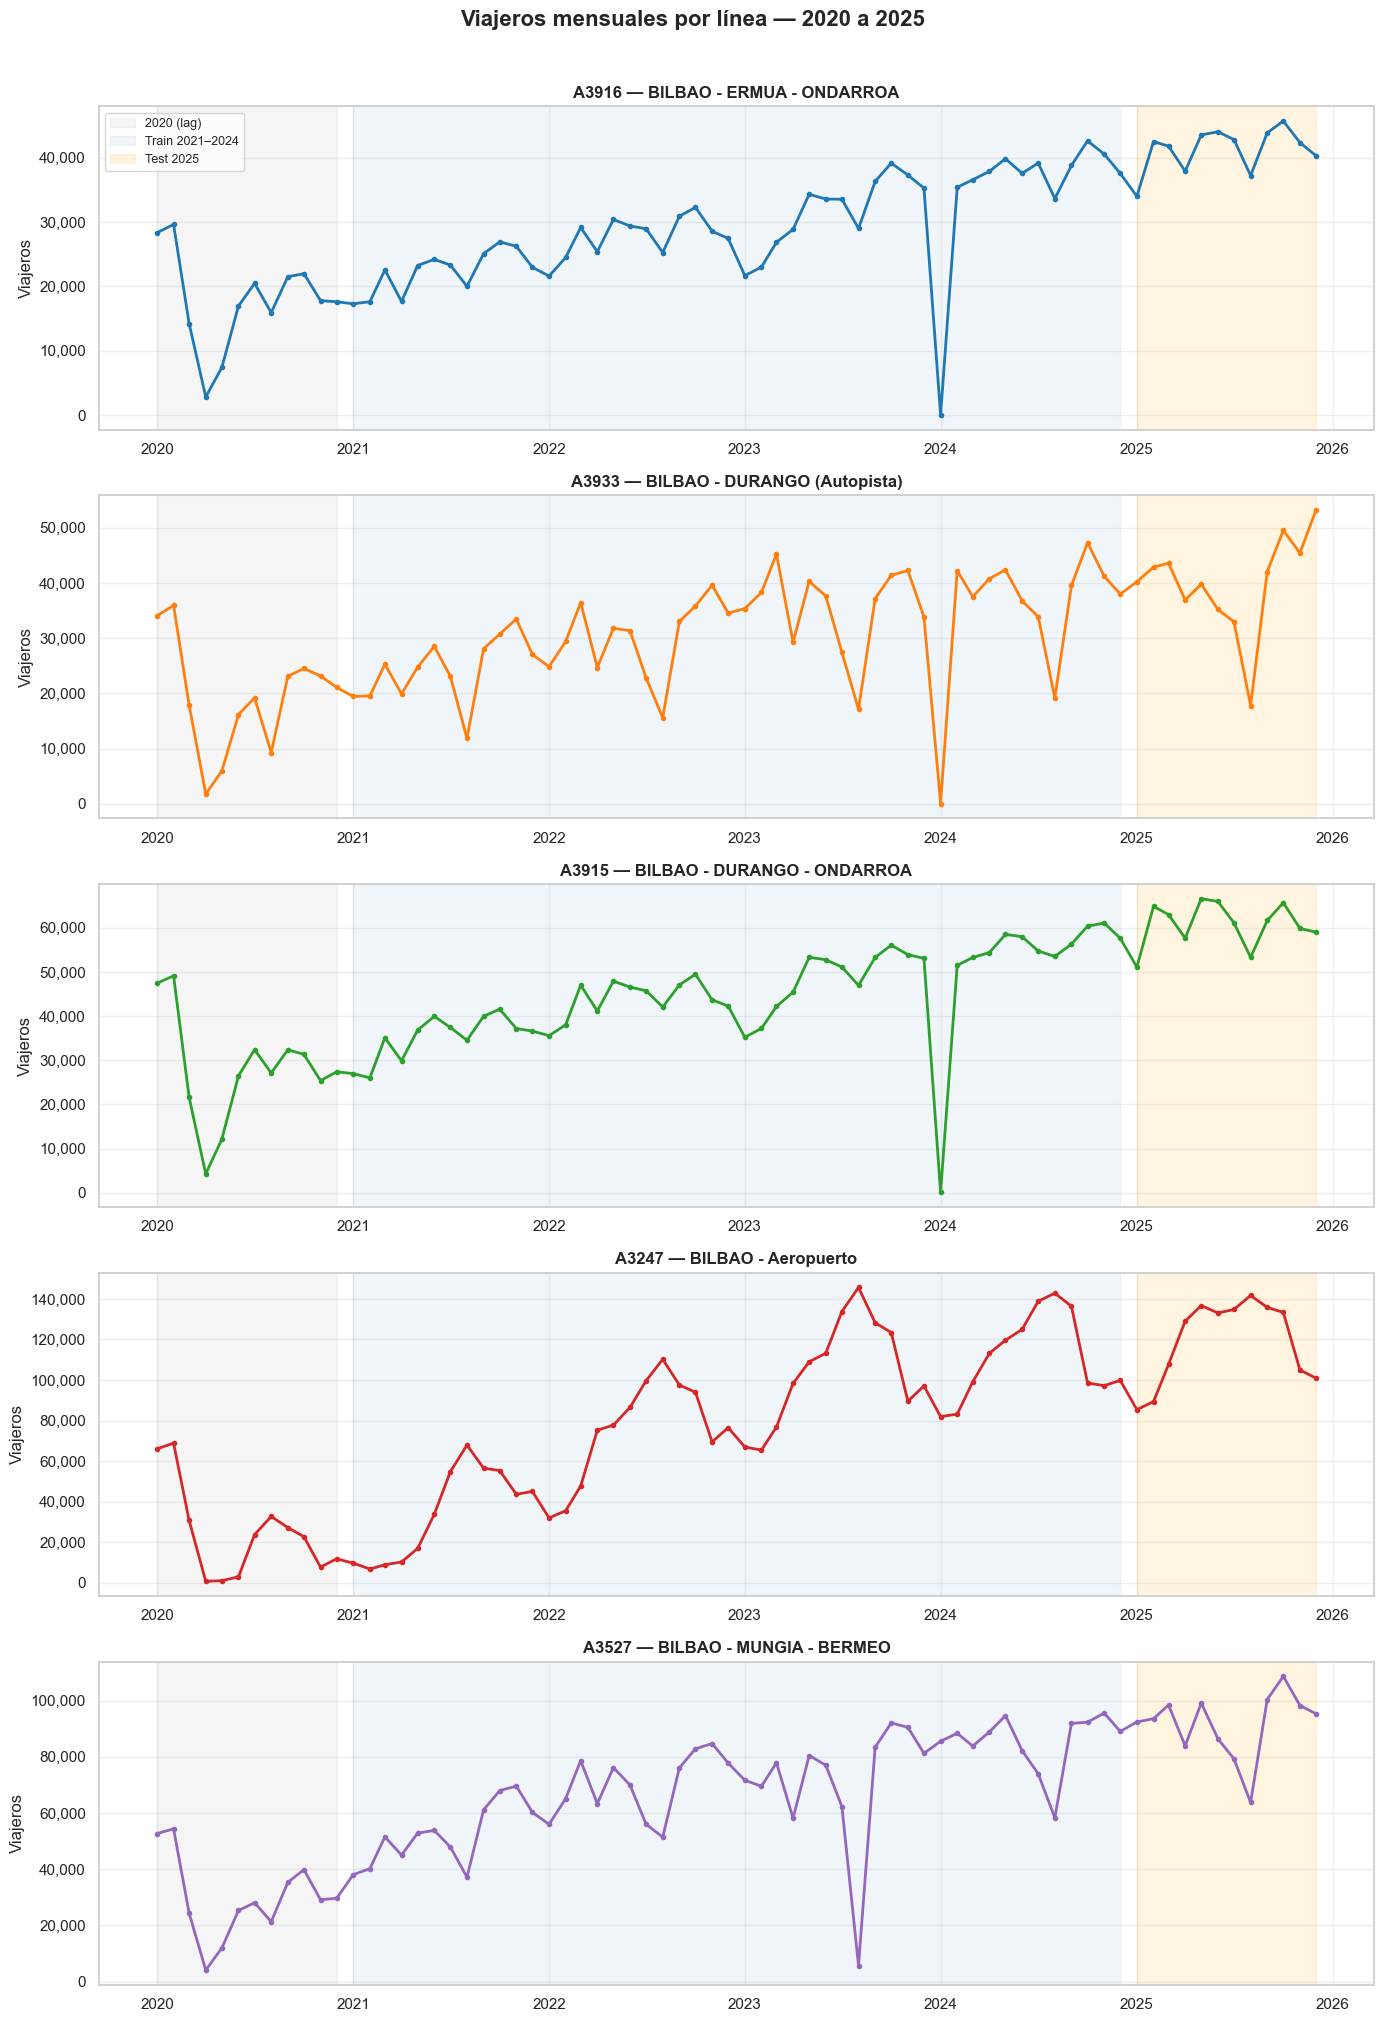

✅ Gráfico guardado como vizualizacion_series.png


In [11]:
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=False)
fig.suptitle('Viajeros mensuales por línea — 2020 a 2025', fontsize=16, fontweight='bold', y=1.01)

colores = sns.color_palette('tab10', 5)

for i, (linea, ax) in enumerate(zip(LINEAS, axes)):
    # Datos completos 2020-2025
    datos = df_monthly[df_monthly['linea'] == linea].sort_values('fecha')
    
    # Zona 2020 (solo lag, no entra en modelo)
    datos_2020 = datos[datos['anio'] == 2020]
    datos_train = datos[(datos['anio'] >= 2021) & (datos['anio'] <= 2024)]
    datos_test  = datos[datos['anio'] == 2025]
    
    ax.axvspan(datos_2020['fecha'].min(), datos_2020['fecha'].max(),
               alpha=0.08, color='gray', label='2020 (lag)')
    ax.axvspan(datos_train['fecha'].min(), datos_train['fecha'].max(),
               alpha=0.08, color='steelblue', label='Train 2021–2024')
    ax.axvspan(datos_test['fecha'].min(), datos_test['fecha'].max(),
               alpha=0.12, color='orange', label='Test 2025')
    
    ax.plot(datos['fecha'], datos['viajeros'], color=colores[i],
            linewidth=2, marker='o', markersize=3)
    
    ax.set_title(f'{linea} — {NOMBRES[linea]}', fontweight='bold')
    ax.set_ylabel('Viajeros')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('vizualizacion_series.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado como vizualizacion_series.png')

## 8. Estadísticas descriptivas del DataFrame de modelado

In [12]:
print('=== Estadísticas generales del df_model ===')
print(df_model[['viajeros', 'viajeros_n1', 't', 'mes']].describe().round(1))

=== Estadísticas generales del df_model ===
       viajeros  viajeros_n1      t    mes
count     300.0        300.0  300.0  300.0
mean    55040.8      45705.2   30.5    6.5
std     30851.0      28976.5   17.3    3.5
min        34.2         34.2    1.0    1.0
25%     34237.2      26179.0   15.8    3.8
50%     45047.5      37569.0   30.5    6.5
75%     75431.8      58022.2   45.2    9.2
max    145608.0     145608.0   60.0   12.0


In [13]:
print('=== Viajeros totales por línea (2021–2025) ===')
resumen_lineas = (
    df_model.groupby('linea')
    .agg(
        nombre=('nombre_linea', 'first'),
        total_viajeros=('viajeros', 'sum'),
        media_mensual=('viajeros', 'mean'),
        registros=('viajeros', 'count')
    )
    .sort_values('total_viajeros', ascending=False)
)
resumen_lineas['total_viajeros'] = resumen_lineas['total_viajeros'].map('{:,.0f}'.format)
resumen_lineas['media_mensual'] = resumen_lineas['media_mensual'].map('{:,.0f}'.format)
resumen_lineas

=== Viajeros totales por línea (2021–2025) ===


,nombre,total_viajeros,media_mensual,registros
linea,,,,
A3247,BILBAO-Aireportua/Aeropuerto,"5,326,652","88,778",60
A3527,BILBAO - MUNGIA - BERMEO (Por la autopista/tik),"4,436,732","73,946",60
A3915,BILBAO - DURANGO - ONDARROA (Autopista),"2,877,562","47,959",60
A3933,BILBAO - DURANGO (Autopista),"1,975,690","32,928",60
A3916,BILBAO - ERMUA - ONDARROA (Autopista),"1,895,602","31,593",60


## 9. Guardado del DataFrame limpio

In [14]:
# Guardamos el DataFrame listo para el Paso 2 (modelado)
df_model.to_csv('bizkaibus_model_data.csv', index=False)
print(f'✅ DataFrame guardado: bizkaibus_model_data.csv')
print(f'   Shape: {df_model.shape}')
print(f'   Columnas: {df_model.columns.tolist()}')
print()
print('=== RESUMEN PASO 1 ===')
print(f'  Líneas: {LINEAS}')
print(f'  Período modelo: {df_model["anio"].min()} – {df_model["anio"].max()}')
print(f'  Features disponibles: t, mes, viajeros_n1')
print(f'  Target: viajeros')
print(f'  Train: 2021–2024 | Test: 2025')
print()
print('▶ Siguiente paso: Paso 2 — Entrenamiento del modelo de regresión lineal múltiple')

✅ DataFrame guardado: bizkaibus_model_data.csv
   Shape: (300, 8)
   Columnas: ['linea', 'anio', 'mes', 'viajeros', 'nombre_linea', 'fecha', 'viajeros_n1', 't']

=== RESUMEN PASO 1 ===
  Líneas: ['A3916', 'A3933', 'A3915', 'A3247', 'A3527']
  Período modelo: 2021 – 2025
  Features disponibles: t, mes, viajeros_n1
  Target: viajeros
  Train: 2021–2024 | Test: 2025

▶ Siguiente paso: Paso 2 — Entrenamiento del modelo de regresión lineal múltiple
